# 4주차 — 텍스트 태스크: 번역과 요약
### 인공지능 플랫폼실습 · 인공지능소프트웨어과

---

## 이번 주 학습 목표
1. 번역 모델과 요약 모델을 불러와 사용할 수 있다.
2. 토큰화 → 생성 → 디코딩의 3단계를 설명할 수 있다.
3. 생성 옵션을 바꿔 결과 길이와 품질을 조절할 수 있다.

## 3주차와 무엇이 다른가
```
3주차 : pipeline() 이 전부 대신해 줌          -> 코드 3줄, 안이 안 보임
4주차 : 토크나이저와 모델을 직접 불러 씀       -> 코드 5줄, 안이 보임
```

> ⏱ 예상 소요 시간: 약 100분
> ※ 모델을 4개 내려받으므로 **첫 실행은 각 1~3분** 걸립니다.


---
# STEP 1. 준비와 확인  (약 15분)


In [1]:
# ============================================================
# [실습 1-1] transformers 설치 및 버전 확인
# ------------------------------------------------------------
# -U 는 이미 있으면 최신으로 올리라는 뜻입니다.
# ============================================================

!pip install -q -U transformers

import transformers, torch
print("transformers 버전 :", transformers.__version__)
print("torch 버전        :", torch.__version__)
print("GPU 사용 가능      :", torch.cuda.is_available())


transformers 버전 : 5.16.1
torch 버전        : 2.11.0+cu128
GPU 사용 가능      : True


### ★ 중요 — 이번 주에는 `pipeline()` 을 쓰지 않습니다

3주차에는 `pipeline("text-classification")` 한 줄이면 됐습니다.
그런데 **transformers 5 버전부터 번역·요약 pipeline이 없어졌습니다.**

아래 셀을 실행해서 직접 확인해 봅시다. (오류가 나는 것이 정상입니다)


In [2]:
# ============================================================
# [실습 1-2] 없어진 pipeline 직접 확인하기  ※ 오류가 나는 것이 정상
# ------------------------------------------------------------
# try / except 는 "오류가 나도 프로그램을 멈추지 말고 처리하라"는 문법입니다.
# 오류 메시지를 직접 보는 것이 이번 셀의 목적입니다.
# ============================================================

from transformers import pipeline

for 작업 in ["summarization", "translation"]:
    try:
        pipeline(작업)
        print(f"{작업:16s} -> 사용 가능")
    except Exception as e:
        print(f"{작업:16s} -> 사용 불가 ({type(e).__name__})")
        print(f"                    {str(e)[:80]} ...")

print("\n지금 버전에서는 위 두 작업을 pipeline으로 쓸 수 없습니다.")
print("대신 모델을 직접 불러 쓰는 방법을 배웁니다. (오히려 안이 더 잘 보입니다)")


summarization    -> 사용 불가 (KeyError)
                    "Unknown task summarization, available tasks are ['any-to-any', 'audio-classific ...
translation      -> 사용 불가 (KeyError)
                    "Unknown task translation, available tasks are ['any-to-any', 'audio-classificat ...

지금 버전에서는 위 두 작업을 pipeline으로 쓸 수 없습니다.
대신 모델을 직접 불러 쓰는 방법을 배웁니다. (오히려 안이 더 잘 보입니다)


> 💡 **왜 없어졌을까요?**
> 번역과 요약은 모두 "문장을 넣어 문장을 만드는" 같은 일입니다.
> 작업 이름을 따로 두는 대신 **모델을 직접 불러 쓰도록** 정리된 것입니다.
> 우리에게는 오히려 좋은 일입니다 — AI가 실제로 어떻게 동작하는지 보이니까요.


---
# STEP 2. 직접 불러 쓰는 3단계  (약 20분)

`pipeline` 이 대신 해 주던 일을 우리가 직접 합니다. 딱 3단계입니다.

```
① 토큰화      문장 -> 숫자        tokenizer(문장)
② 생성        숫자 -> 숫자        model.generate(...)
③ 디코딩      숫자 -> 문장        tokenizer.decode(...)
```


In [3]:
# ============================================================
# [실습 2-1] 번역 모델 불러오기 (한국어 -> 영어)
# ------------------------------------------------------------
# AutoTokenizer            : 문장을 숫자로 바꾸는 도구
# AutoModelForSeq2SeqLM    : 문장을 넣어 문장을 만드는 모델
#   Seq2Seq = Sequence to Sequence (문장 -> 문장)
# 첫 실행은 모델을 내려받느라 1~3분 걸립니다.
# ============================================================

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

번역_모델이름 = "Helsinki-NLP/opus-mt-ko-en"

번역_토크나이저 = AutoTokenizer.from_pretrained(번역_모델이름)
번역_모델 = AutoModelForSeq2SeqLM.from_pretrained(번역_모델이름)

print("불러온 모델 :", 번역_모델이름)
print("모델 종류   :", type(번역_모델).__name__)


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  312MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

불러온 모델 : Helsinki-NLP/opus-mt-ko-en
모델 종류   : MarianMTModel


In [4]:
# ============================================================
# [실습 2-2] ① 토큰화 — 문장이 숫자로 바뀌는 것 직접 보기
# ------------------------------------------------------------
# return_tensors="pt" 는 파이토치(torch)가 쓰는 형식으로 달라는 뜻입니다.
# ============================================================

원문 = "오늘 날씨가 정말 좋아서 산책을 다녀왔습니다."

입력 = 번역_토크나이저(원문, return_tensors="pt")

print("원문      :", 원문)
print("숫자 모양 :", 입력["input_ids"].shape, " -> (문장 1개, 토큰 N개)")
print("숫자      :", 입력["input_ids"][0].tolist())

# 숫자를 다시 글자 조각으로 되돌려 보기
조각들 = 번역_토크나이저.convert_ids_to_tokens(입력["input_ids"][0])
print("\n토큰 조각 :", 조각들)
print("토큰 개수 :", len(조각들))


원문      : 오늘 날씨가 정말 좋아서 산책을 다녀왔습니다.
숫자 모양 : torch.Size([1, 12])  -> (문장 1개, 토큰 N개)
숫자      : [1114, 15291, 62, 516, 803, 212, 31827, 51, 16152, 4709, 2, 0]

토큰 조각 : ['▁오늘', '▁날씨', '가', '▁정말', '▁좋아', '서', '▁산책', '을', '▁다녀', '왔습니다', '.', '</s>']
토큰 개수 : 12


> 💡 **토큰은 '단어'가 아닙니다.**
> 모델이 아는 조각 단위로 잘립니다. 한 단어가 여러 조각으로 쪼개지기도 합니다.
> 마지막의 `</s>` 는 "문장 끝"을 뜻하는 특별한 토큰입니다.


In [5]:
# ============================================================
# [실습 2-3] ② 생성 — 모델이 새 숫자를 만들어 냄
# ------------------------------------------------------------
# generate( ) 는 "이 입력을 보고 다음 문장을 만들어라"는 명령입니다.
#   max_new_tokens : 최대 몇 개의 토큰까지 만들지
# ============================================================

출력_숫자 = 번역_모델.generate(**입력, max_new_tokens=60)

print("만들어진 숫자 모양 :", 출력_숫자.shape)
print("만들어진 숫자      :", 출력_숫자[0].tolist())


[transformers] Both `max_new_tokens` (=60) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


만들어진 숫자 모양 : torch.Size([1, 15])
만들어진 숫자      : [65000, 16, 608, 26, 11, 1726, 422, 211, 4, 6358, 35, 100, 186, 2, 0]


In [6]:
# ============================================================
# [실습 2-4] ③ 디코딩 — 숫자를 다시 사람 문장으로
# ------------------------------------------------------------
# skip_special_tokens=True 는 </s> 같은 특별 토큰을 빼고 보여달라는 뜻입니다.
# ============================================================

번역문 = 번역_토크나이저.decode(출력_숫자[0], skip_special_tokens=True)

print("원문   :", 원문)
print("번역문 :", 번역문)


원문   : 오늘 날씨가 정말 좋아서 산책을 다녀왔습니다.
번역문 : I went for a walk today because the weather was so good.


### ✅ 확인 체크포인트
영어 문장이 나왔으면 성공입니다. 완벽하지 않아도 괜찮습니다.

지금 한 3단계가 3주차의 `pipeline()` 한 줄 안에서 벌어지던 일입니다.


---
# STEP 3. 함수로 묶어 편하게 쓰기  (약 15분)

매번 3단계를 쓰기는 번거롭습니다. 함수로 한 번만 만들어 두고 계속 씁니다.


In [7]:
# ============================================================
# [실습 3-1] 번역 함수 만들기
# ------------------------------------------------------------
# 앞의 3단계를 그대로 함수 안에 넣었습니다.
# 재료(문장)를 주면 결과(번역문)를 돌려줍니다.
# ============================================================

def 번역하기(문장, 최대길이=80):
    """한국어 문장을 받아 영어 번역문을 돌려준다"""
    입력 = 번역_토크나이저(문장, return_tensors="pt", truncation=True, max_length=512)
    출력 = 번역_모델.generate(**입력, max_new_tokens=최대길이)
    return 번역_토크나이저.decode(출력[0], skip_special_tokens=True)


print(번역하기("인공지능 플랫폼 실습 수업은 매주 화요일에 있습니다."))
print(번역하기("이 모델은 코드 몇 줄로 불러올 수 있습니다."))


[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AI platform practice class is on Tuesday every week.
This model can be loaded with a few lines of code.


In [8]:
# ============================================================
# [실습 3-2] 여러 문장 한 번에 번역하기
# ------------------------------------------------------------
# 문장을 리스트로 넣고 padding=True 를 주면 한 번에 처리됩니다.
#   padding=True : 길이가 다른 문장들의 길이를 맞춰 줍니다
# batch_decode 는 여러 결과를 한 번에 문장으로 되돌립니다.
# ============================================================

문장들 = [
    "오늘 수업에서 번역 모델을 배웠습니다.",
    "인공지능은 생각보다 어렵지 않습니다.",
    "과제는 다음 주 전날까지 제출해야 합니다.",
]

입력들 = 번역_토크나이저(문장들, return_tensors="pt", padding=True, truncation=True)
출력들 = 번역_모델.generate(**입력들, max_new_tokens=80)
번역들 = 번역_토크나이저.batch_decode(출력들, skip_special_tokens=True)

for 한국어, 영어 in zip(문장들, 번역들):
    print(f"[KO] {한국어}")
    print(f"[EN] {영어}\n")


[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[KO] 오늘 수업에서 번역 모델을 배웠습니다.
[EN] I learned the translation model in my class today.

[KO] 인공지능은 생각보다 어렵지 않습니다.
[EN] AI isn't as hard as I thought it would be.

[KO] 과제는 다음 주 전날까지 제출해야 합니다.
[EN] The assignment has to be submitted by next week.



---
# STEP 4. 반대 방향 번역과 되돌림 검사  (약 15분)

모델을 바꾸면 방향도 바뀝니다. **모델 이름 한 줄만** 바꾸면 됩니다.


In [9]:
# ============================================================
# [실습 4-1] 영어 -> 한국어 모델 불러오기
# ------------------------------------------------------------
# 앞에서 쓴 모델은 ko-en (한국어->영어) 였습니다.
# 이번에는 en-ko (영어->한국어) 모델을 씁니다.
#
# ★ 미리 알아 둘 것 — 이 모델은 실력이 좋지 않습니다.
#   모델 카드에 적힌 점수(BLEU)를 비교해 보면
#     한국어 -> 영어  opus-mt-ko-en          : BLEU 41.3
#     영어 -> 한국어  opus-mt-tc-big-en-ko   : BLEU 13.7   <- 낮음
#   번역이 어색하게 나오는 것이 정상입니다.
#   왜 그런지는 실습 4-2, 4-3에서 직접 확인합니다.
# ============================================================

역번역_모델이름 = "Helsinki-NLP/opus-mt-tc-big-en-ko"

역_토크나이저 = AutoTokenizer.from_pretrained(역번역_모델이름)
역_모델 = AutoModelForSeq2SeqLM.from_pretrained(역번역_모델이름)


def 역번역하기(문장, 최대길이=80):
    """영어 문장을 받아 한국어 번역문을 돌려준다"""
    입력 = 역_토크나이저(문장, return_tensors="pt", truncation=True, max_length=512)
    출력 = 역_모델.generate(**입력, max_new_tokens=최대길이)
    return 역_토크나이저.decode(출력[0], skip_special_tokens=True)


print(역번역하기("Machine translation is useful for reading foreign documents."))

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

source.spm: reconstructing file:   0%|          |  0.00B /  790kB            

source.spm: downloading bytes:           |  0.00B            

target.spm: reconstructing file:   0%|          |  0.00B /  815kB            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


게이                         .


In [10]:
# ============================================================
# [실습 4-2] 되돌림 번역(back-translation)으로 품질 확인하기
# ------------------------------------------------------------
# 한국어 -> 영어 -> 다시 한국어 로 돌려서 원문과 비교합니다.
# 정답이 없는 작업에서 품질을 가늠하는 간단한 방법입니다.
#
# ★ 되돌림 문장이 원문과 많이 다르게 나올 것입니다. 그것이 정상입니다.
#   코드가 틀린 것이 아니라 en-ko 모델의 실력이 부족한 것입니다.
#   "어디가 어떻게 망가지는지" 직접 보는 것이 이 단계의 목적입니다.
# ============================================================

원문들 = [
    "이번 학기에는 인공지능 플랫폼을 배웁니다.",
    "그 영화는 생각보다 별로였어요.",
    "내일 비가 오면 소풍은 취소됩니다.",
]

for 원문 in 원문들:
    영어 = 번역하기(원문)
    되돌림 = 역번역하기(영어)
    print(f"원문   : {원문}")
    print(f"영어   : {영어}")
    print(f"되돌림 : {되돌림}")
    print("        -> 원문과 같은 뜻인가요? 다르다면 어느 부분이 달라졌나요?")
    print("-" * 60)

[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


원문   : 이번 학기에는 인공지능 플랫폼을 배웁니다.
영어   : This semester, we're learning the AI platform.
되돌림 : PI☆, 유니버설 호텔 컬러☆ well row☆.
        -> 원문과 같은 뜻인가요? 다르다면 어느 부분이 달라졌나요?
------------------------------------------------------------


[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


원문   : 그 영화는 생각보다 별로였어요.
영어   : That movie wasn't as good as I thought it would be.
되돌림 : 여러분 메탄 호텔 탱크에서 HK 탱크 미국 할머니 CD 약탈 대학.
        -> 원문과 같은 뜻인가요? 다르다면 어느 부분이 달라졌나요?
------------------------------------------------------------


[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


원문   : 내일 비가 오면 소풍은 취소됩니다.
영어   : When it rains tomorrow, the picnic is canceled.
되돌림 : GET CD-ing-ing-, 잘- 인기 있는-.
        -> 원문과 같은 뜻인가요? 다르다면 어느 부분이 달라졌나요?
------------------------------------------------------------


> ⚠️ **되돌림 문장이 이상하게 나왔나요? 잘 하신 겁니다.**
>
> 이것은 버그가 아니라 **모델의 실력 차이**입니다.
> `opus-mt-tc-big-en-ko` 는 모델 카드에 **BLEU 13.7** 이라고 적혀 있습니다.
> 한국어→영어 모델(BLEU 41.3)의 3분의 1 수준입니다.
>
> **모델 카드에 적힌 숫자가 실제 결과로 그대로 나타난다** — 이번 주에서 가장 중요한 교훈입니다.
> 다음 셀에서 더 좋은 모델로 바꿔 같은 문장을 다시 돌려 봅니다.

In [14]:
# ============================================================
# [실습 4-3] 영어 -> 한국어 모델 3개 비교하기
# ------------------------------------------------------------
# 기존 1 : Helsinki-NLP/opus-mt-tc-big-en-ko
#           (모델 카드 BLEU 13.7)
#
# 기존 2 : NHNDQ/nllb-finetuned-en2ko
#           (모델 카드 BLEU 33.66)
#
# 과제 추가 : Neurora/opus-hplt-en-ko-v2.0
#
# 기존 모델 2개 + 내가 추가한 모델 1개를 비교합니다.
# 메모리 사용을 줄이기 위해 모델 사용이 끝나면 제거합니다.
# ============================================================

import gc
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


# 1. 사용할 장치 설정

장치 = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("사용 장치 :", 장치)


# 2. 먼저 한국어 원문을 영어로 번역

영어결과들 = []

for 원문 in 원문들:

    영어 = 번역하기(원문)

    영어결과들.append(영어)


# 3. 기존 모델 1
#    Helsinki-NLP/opus-mt-tc-big-en-ko

기존_Helsinki_결과 = []

for 영어 in 영어결과들:

    결과 = 역번역하기(영어)

    기존_Helsinki_결과.append(결과)


# 4. 기존 모델 2
#    NHNDQ/nllb-finetuned-en2ko


좋은역_모델이름 = "NHNDQ/nllb-finetuned-en2ko"

print("\n기존 교체 모델 불러오는 중 :", 좋은역_모델이름)


좋은역_토크나이저 = AutoTokenizer.from_pretrained(
    좋은역_모델이름,
    src_lang="eng_Latn"
)

좋은역_모델 = AutoModelForSeq2SeqLM.from_pretrained(
    좋은역_모델이름
)

좋은역_모델 = 좋은역_모델.to(장치)


# 목표 언어를 한국어로 지정
한국어_번호 = 좋은역_토크나이저.convert_tokens_to_ids(
    "kor_Hang"
)

print("한국어를 가리키는 토큰 번호 :", 한국어_번호)


# NHNDQ 결과 저장
기존_NHNDQ_결과 = []


for 영어 in 영어결과들:

    입력 = 좋은역_토크나이저(
        영어,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    입력 = {
        이름: 값.to(장치)
        for 이름, 값 in 입력.items()
    }


    with torch.no_grad():

        출력 = 좋은역_모델.generate(
            **입력,
            forced_bos_token_id=한국어_번호,
            max_new_tokens=80
        )


    결과 = 좋은역_토크나이저.decode(
        출력[0].detach().cpu(),
        skip_special_tokens=True
    )

    기존_NHNDQ_결과.append(결과)



# NHNDQ 모델 사용 완료 -> 메모리 정리

del 좋은역_모델
del 좋은역_토크나이저

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✅ NHNDQ 결과 생성 완료 / 메모리 정리 완료")


# 5. 내가 추가한 경량 모델
#    Neurora/opus-hplt-en-ko-v2.0

추가_모델이름 = "Neurora/opus-hplt-en-ko-v2.0"

print("\n추가 모델 불러오는 중 :", 추가_모델이름)


추가_토크나이저 = AutoTokenizer.from_pretrained(
    추가_모델이름
)

추가_모델 = AutoModelForSeq2SeqLM.from_pretrained(
    추가_모델이름
)

추가_모델 = 추가_모델.to(장치)


추가_Neurora_결과 = []


for 영어 in 영어결과들:

    입력 = 추가_토크나이저(
        영어,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    입력 = {
        이름: 값.to(장치)
        for 이름, 값 in 입력.items()
    }


    with torch.no_grad():

        출력 = 추가_모델.generate(
            **입력,
            max_new_tokens=80,
            num_beams=4
        )


    결과 = 추가_토크나이저.decode(
        출력[0].detach().cpu(),
        skip_special_tokens=True
    )

    추가_Neurora_결과.append(결과)


# Neurora 모델 사용 완료 -> 메모리 정리

del 추가_모델
del 추가_토크나이저

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✅ Neurora 결과 생성 완료 / 메모리 정리 완료")



# 6. 세 모델의 결과를 한 번에 비교

print("\n")
print("=" * 80)
print("영어 -> 한국어 역번역 모델 3개 비교")
print("=" * 80)


for i in range(len(원문들)):

    print(f"\n[문장 {i + 1}]")

    print("원문                 :", 원문들[i])

    print("영어 번역            :", 영어결과들[i])

    print("기존 Helsinki        :", 기존_Helsinki_결과[i])

    print("기존 NHNDQ NLLB      :", 기존_NHNDQ_결과[i])

    print("내가 추가한 Neurora  :", 추가_Neurora_결과[i])

    print("-" * 80)


# 7. 비교 기준

print("\n[비교 기준]")

print("1. 원문의 의미가 얼마나 유지되는가")
print("2. 한국어 문장이 자연스러운가")
print("3. 중요한 내용이 빠지지 않았는가")
print("4. 원문에 없는 내용이 추가되지 않았는가")

[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


사용 장치 : cuda


[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/


기존 교체 모델 불러오는 중 : NHNDQ/nllb-finetuned-en2ko


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 2.47GB            

...

[transformers] Both `max_new_tokens` (=80) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer NllbTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_lengt

✅ NHNDQ 결과 생성 완료 / 메모리 정리 완료

추가 모델 불러오는 중 : Neurora/opus-hplt-en-ko-v2.0


Loading weights:   0%|          | 0/255 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Neurora 결과 생성 완료 / 메모리 정리 완료


영어 -> 한국어 역번역 모델 3개 비교

[문장 1]
원문                 : 이번 학기에는 인공지능 플랫폼을 배웁니다.
영어 번역            : This semester, we're learning the AI platform.
기존 Helsinki        : PI☆, 유니버설 호텔 컬러☆ well row☆.
기존 NHNDQ NLLB      : 이번 학기에는 AI 플랫폼을 배우게 되었습니다.
내가 추가한 Neurora  : 이제 AI 플랫폼을 학습하고 있습니다.
--------------------------------------------------------------------------------

[문장 2]
원문                 : 그 영화는 생각보다 별로였어요.
영어 번역            : That movie wasn't as good as I thought it would be.
기존 Helsinki        : 여러분 메탄 호텔 탱크에서 HK 탱크 미국 할머니 CD 약탈 대학.
기존 NHNDQ NLLB      : 그 영화는 내가 생각했던 것만큼 좋지 않았어.
내가 추가한 Neurora  : 그 영화는 그것이 될 것이라고 생각만큼 좋지 않았습니다.
--------------------------------------------------------------------------------

[문장 3]
원문                 : 내일 비가 오면 소풍은 취소됩니다.
영어 번역            : When it rains tomorrow, the picnic is canceled.
기존 Helsinki        : GET CD-ing-ing-, 잘- 인기 있는-.
기존 NHNDQ NLLB      : 내일 비가 오면 소풍은 취소됩니다.
내가 추가한 Neurora  : 내일 비가 오면 피크닉이 취소됩니다.
-------

> ✅ **여기서 배운 것**
>
> | | 기존 모델 | 교체 모델 |
> |---|---|---|
> | 이름 | `opus-mt-tc-big-en-ko` | `NHNDQ/nllb-finetuned-en2ko` |
> | 모델 카드 BLEU | 13.7 | 33.66 |
> | 크기 | 작음 (빠름) | 2.4GB (느림) |
>
> **바꾼 것은 모델 이름 한 줄뿐인데 결과가 완전히 달라집니다.**
> 모델을 고르는 일이 코드를 잘 짜는 일보다 결과에 더 큰 영향을 줄 때가 많습니다.

---
# STEP 5. 요약하기  (약 20분)

요약도 번역과 **똑같은 3단계**입니다. 모델만 바뀝니다.


In [15]:
# ============================================================
# [실습 5-1] 영어 요약 모델 불러오기
# ------------------------------------------------------------
# distilbart-cnn : 뉴스 기사로 학습된 영어 요약 모델
# ============================================================

요약_모델이름 = "sshleifer/distilbart-cnn-12-6"

요약_토크나이저 = AutoTokenizer.from_pretrained(요약_모델이름)
요약_모델 = AutoModelForSeq2SeqLM.from_pretrained(요약_모델이름)

print("요약 모델 준비 완료 :", 요약_모델이름)


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.22GB            

...

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.22GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

요약 모델 준비 완료 : sshleifer/distilbart-cnn-12-6


In [16]:
# ============================================================
# [실습 5-2] 긴 영어 글 요약하기
# ------------------------------------------------------------
#   min_new_tokens : 최소 이만큼은 만들어라 (너무 짧아지는 것 방지)
#   max_new_tokens : 최대 이만큼까지만
#   num_beams      : 후보를 몇 개 놓고 비교할지 (클수록 좋지만 느림)
# ============================================================

긴글 = """
Hugging Face is a company that hosts an open platform for machine learning models.
Developers around the world upload models, datasets and demo applications there.
Anyone can download a model with a single line of code and use it in their own program.
Because the models are already trained, users do not need expensive hardware or
large amounts of data. This has made advanced language technology available to
students, small companies and researchers who could not afford it before.
"""

입력 = 요약_토크나이저(긴글, return_tensors="pt", truncation=True, max_length=1024)
출력 = 요약_모델.generate(**입력, max_new_tokens=60, min_new_tokens=20, num_beams=4)
요약문 = 요약_토크나이저.decode(출력[0], skip_special_tokens=True)

print("원문 길이 :", len(긴글.split()), "단어")
print("요약 길이 :", len(요약문.split()), "단어")
print("\n[요약]\n", 요약문.strip())


[transformers] Both `max_new_tokens` (=60) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=20) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


원문 길이 : 79 단어
요약 길이 : 36 단어

[요약]
 Anyone can download a model with a single line of code and use it in their own program . The models are already trained, users do not need expensive hardware or large amounts of data .


In [20]:
# ============================================================
# [실습 5-3] 한국어 요약 모델 5개 비교하기
# ============================================================

import gc
import torch

from transformers import (
    PreTrainedTokenizerFast,
    AutoModelForSeq2SeqLM
)

한국어_긴글 = """
한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는
고등교육기관이다. 인공지능소프트웨어과에서는 파이썬 기초부터 시작해 공개된 인공지능
플랫폼을 활용하는 방법을 배운다. 학생들은 직접 데이터를 모아 모델을 학습시켜 보고,
이미 공개된 모델을 가져와 서비스 형태로 만들어 인터넷에 배포하는 경험까지 하게 된다.
이 과정에서 별도의 고가 장비 없이 무료로 제공되는 클라우드 자원만으로 실습을 진행한다.
""".strip()

장치 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치 :", 장치)
print("[원문]", len(한국어_긴글), "글자\n")


def 메모리_정리():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def 카바트_요약(모델이름, 글):

    토크나이저 = PreTrainedTokenizerFast.from_pretrained(
        모델이름
    )

    모델 = AutoModelForSeq2SeqLM.from_pretrained(
        모델이름
    ).to(장치)

    입력번호 = 토크나이저.encode(글)

    입력번호 = (
        [토크나이저.bos_token_id]
        + 입력번호
        + [토크나이저.eos_token_id]
    )

    입력 = torch.tensor(
        [입력번호],
        device=장치
    )

    with torch.no_grad():

        출력 = 모델.generate(
            입력,
            num_beams=4,
            min_length=10,
            max_length=64
        )

    결과 = 토크나이저.decode(
        출력[0].detach().cpu(),
        skip_special_tokens=True
    ).strip()

    del 모델
    del 토크나이저
    del 입력
    del 출력

    메모리_정리()

    return 결과


def 티파이브_요약(모델이름, 글):

    # C와 E는 같은 pko-T5 기반 토크나이저 사용
    토크나이저 = PreTrainedTokenizerFast.from_pretrained(
        "paust/pko-t5-base"
    )

    모델 = AutoModelForSeq2SeqLM.from_pretrained(
        모델이름
    ).to(장치)

    입력 = 토크나이저(
        ["summarize: " + 글],
        max_length=512,
        truncation=True,
        return_tensors="pt"
    )

    입력 = {
        이름: 값.to(장치)
        for 이름, 값 in 입력.items()
    }

    with torch.no_grad():

        출력 = 모델.generate(
            **입력,
            num_beams=3,
            min_length=10,
            max_length=64
        )

    결과 = 토크나이저.batch_decode(
        출력,
        skip_special_tokens=True
    )[0].strip()

    del 모델
    del 토크나이저
    del 입력
    del 출력

    메모리_정리()

    return 결과


후보들 = [

    (
        "A",
        "기존",
        "EbanLee/kobart-summary-v3",
        카바트_요약
    ),

    (
        "B",
        "기존",
        "gogamza/kobart-summarization",
        카바트_요약
    ),

    (
        "C",
        "기존",
        "eenzeenee/t5-base-korean-summarization",
        티파이브_요약
    ),

    (
        "D",
        "내가 추가",
        "digit82/kobart-summarization",
        카바트_요약
    ),

    (
        "E",
        "내가 추가",
        "lcw99/t5-base-korean-text-summary",
        티파이브_요약
    )
]


요약결과들 = {}


for 기호, 구분, 모델이름, 요약함수 in 후보들:

    print("=" * 80)
    print(f"[{기호}] [{구분}] {모델이름}")

    try:

        결과 = 요약함수(
            모델이름,
            한국어_긴글
        )

        요약결과들[기호] = 결과

        print("결과 :", 결과)

    except Exception as 오류:

        요약결과들[기호] = None

        print(
            "실행 실패 :",
            type(오류).__name__,
            str(오류)[:200]
        )

    print()


print("\n" + "=" * 80)
print("한국어 요약 모델 5개 최종 비교")
print("=" * 80)


for 기호, 구분, 모델이름, 요약함수 in 후보들:

    print(f"\n[{기호}] [{구분}]")
    print("모델 :", 모델이름)

    if 요약결과들[기호] is None:
        print("요약 : 실행 실패")
    else:
        print("요약 :", 요약결과들[기호])


print("\n" + "=" * 80)
print("[비교 기준]")
print("1. 원문의 핵심 내용이 유지되는가")
print("2. 원문에 없는 내용이 추가되지 않았는가")
print("3. 문장이 자연스럽고 반복되지 않는가")
print("4. 요약문의 길이가 적절한가")

사용 장치 : cuda
[원문] 240 글자

[A] [기존] EbanLee/kobart-summary-v3


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

결과 : 한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관이다.

[B] [기존] gogamza/kobart-summarization


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

결과 : 한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 교육기관으로 인공지능소프트웨어과에서는 파이썬 기초부터 시작해 공개된 인공지능
플랫폼을 활용하는 방법을 배운다.

[C] [기존] eenzeenee/t5-base-korean-summarization


...

Loading weights:   0%|          | 0/262 [00:00<?, ?it/s]

결과 : 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관으로 인공지능소프트웨어과에서는 파이썬 기초부터 공개된 인공지능
플랫폼을 활용하는 방법을 배운다.

[E] [내가 추가] lcw99/t5-base-korean-text-summary


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


결과 : 한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관이다.


한국어 요약 모델 5개 최종 비교

[A] [기존]
모델 : EbanLee/kobart-summary-v3
요약 : 한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관이다.

[B] [기존]
모델 : gogamza/kobart-summarization
요약 : 한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 교육기관으로 인공지능소프트웨어과에서는 파이썬 기초부터 시작해 공개된 인공지능
플랫폼을 활용하는 방법을 배운다.

[C] [기존]
모델 : eenzeenee/t5-base-korean-summarization
요약 : 한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관으로 인공지능소프트웨어과에서는 파이썬 기초부터 인공지능 플랫폼을 활용하는 방법을 배운다

[D] [내가 추가]
모델 : digit82/kobart-summarization
요약 : 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관으로 인공지능소프트웨어과에서는 파이썬 기초부터 공개된 인공지능
플랫폼을 활용하는 방법을 배운다.

[E] [내가 추가]
모델 : lcw99/t5-base-korean-text-summary
요약 : 한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관이다.

[비교 기준]
1. 원문의 핵심 내용이 유지되는가
2. 원문에 없는 내용이 추가되지 않았는가
3. 문장이 자연스럽고 반복되지 않는가
4. 요약문의 길이가 적절한가


> 🔍 **세 결과를 이렇게 비교해 보세요**
>
> 1. 원문에 없는 내용을 지어내지는 않았는가
> 2. 문장이 중간에 끊기거나 같은 말을 반복하지 않는가
> 3. 원문의 핵심(무엇을 하는 학교/학과인지)이 남아 있는가
>
> 요약에는 정답이 없습니다. **"맞았다"가 아니라 "쓸 만한가"로 판단**합니다.

In [28]:
# ============================================================
# [실습 5-4] 선택한 모델로 요약 함수 만들기
# ============================================================

고른_기호 = "C"
한요약_모델이름 = "eenzeenee/t5-base-korean-summarization"

한요약_토크나이저 = PreTrainedTokenizerFast.from_pretrained(
    "paust/pko-t5-base"
)

한요약_모델 = AutoModelForSeq2SeqLM.from_pretrained(
    한요약_모델이름
).to(장치)


def 요약하기(글, 최대길이=64, 최소길이=12, 빔=4):

    입력 = 한요약_토크나이저(
        "summarize: " + 글.strip(),
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    입력 = {
        이름: 값.to(장치)
        for 이름, 값 in 입력.items()
    }

    with torch.no_grad():
        출력 = 한요약_모델.generate(
            **입력,
            max_new_tokens=최대길이,
            min_new_tokens=최소길이,
            num_beams=빔
        )

    return 한요약_토크나이저.decode(
        출력[0].detach().cpu(),
        skip_special_tokens=True
    ).strip()


print("내가 고른 모델 :", 한요약_모델이름)
print("\n[요약]\n", 요약하기(한국어_긴글))

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


내가 고른 모델 : eenzeenee/t5-base-korean-summarization

[요약]
 한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관으로 인공지능소프트웨어과에서는 파이썬 기초부터 인공지능 플랫폼을 활용하는 방법을 배운다.


---
# STEP 6. 생성 옵션 바꿔보기  (약 15분)

같은 모델이라도 옵션에 따라 결과가 달라집니다. 직접 바꿔 봅시다.


In [29]:
# ============================================================
# [실습 6-1] 길이 옵션 비교하기
# ------------------------------------------------------------
# max_new_tokens 를 바꾸면 요약 길이가 달라집니다.
# ============================================================

for 길이 in [24, 48, 96]:
    결과 = 요약하기(한국어_긴글, 최대길이=길이, 최소길이=8)
    print(f"[max_new_tokens={길이:3d}] ({len(결과)}글자)")
    print("  ", 결과, "\n")


[transformers] Both `max_new_tokens` (=24) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=48) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[max_new_tokens= 24] (35글자)
   한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 



[transformers] Both `max_new_tokens` (=96) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[max_new_tokens= 48] (57글자)
   한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관이다. 

[max_new_tokens= 96] (103글자)
   한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관으로 인공지능소프트웨어과에서는 파이썬 기초부터 인공지능 플랫폼을 활용하는 방법을 배운다. 



In [30]:
# ============================================================
# [실습 6-2] num_beams 비교하기 (품질 vs 속도)
# ------------------------------------------------------------
# time 모듈로 걸린 시간을 재 봅니다.
# beam 이 클수록 후보를 많이 비교해서 대체로 좋아지지만 느려집니다.
# ============================================================

import time

for 빔 in [1, 4, 8]:
    시작 = time.time()
    결과 = 요약하기(한국어_긴글, 빔=빔)
    걸린시간 = time.time() - 시작
    print(f"[num_beams={빔}] {걸린시간:.1f}초")
    print("  ", 결과, "\n")


[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[num_beams=1] 1.4초
   한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관이다. 인공지능소프트웨어과에서는 파이썬 기초부터 인공지능 플랫폼을 활용하는 방법을 배운다 



[transformers] Both `max_new_tokens` (=64) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[num_beams=4] 1.5초
   한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관으로 인공지능소프트웨어과에서는 파이썬 기초부터 인공지능 플랫폼을 활용하는 방법을 배운다. 

[num_beams=8] 1.6초
   한국폴리텍대학은 실무 중심 교육을 통해 산업 현장이 필요로 하는 기술 인력을 길러내는 고등교육기관으로 인공지능소프트웨어과에서는 파이썬 기초부터 인공지능 플랫폼을 활용하는 방법을 배운다. 



---
# STEP 7. 결과를 그래프로 보기  (약 10분)


In [31]:
# ============================================================
# [실습 7-1] 한글 폰트 설치 + 적용  ※ 1~3주차와 같은 코드 (1~2분)
# ------------------------------------------------------------
# 설치와 등록을 한 셀에 함께 넣어야 FileNotFoundError 가 나지 않습니다.
# ============================================================

!apt-get install -y -qq fonts-nanum

import glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_files = glob.glob("/usr/share/fonts/**/Nanum*.ttf", recursive=True)
if len(font_files) == 0:
    print("❌ 폰트를 찾지 못했습니다. 이 셀을 한 번 더 실행하세요.")
else:
    FONT = ([p for p in font_files if p.endswith("NanumGothic.ttf")]
            or sorted(font_files))[0]
    fm.fontManager.addfont(FONT)
    plt.rcParams["font.family"] = fm.FontProperties(fname=FONT).get_name()
    plt.rcParams["axes.unicode_minus"] = False
    print("✅ 한글 폰트 준비 완료 :", plt.rcParams["font.family"])


✅ 한글 폰트 준비 완료 : ['NanumGothic']


[transformers] Both `max_new_tokens` (=24) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=48) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=96) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


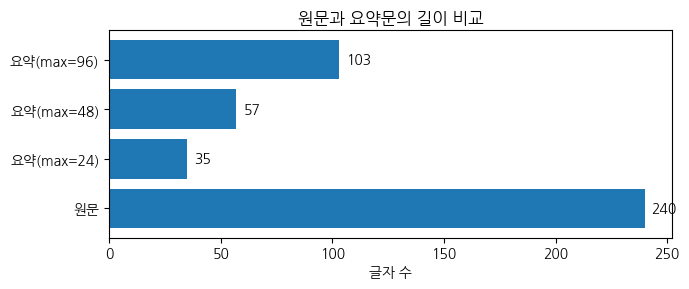

압축률 : 43% 로 줄어듦


In [32]:
# ============================================================
# [실습 7-2] 원문과 요약문 길이를 막대그래프로 비교
# ------------------------------------------------------------
# 요약이 실제로 얼마나 줄여 주는지 눈으로 확인합니다.
# ============================================================

import matplotlib.pyplot as plt

원문길이 = len(한국어_긴글.strip())
요약결과 = {길이: 요약하기(한국어_긴글, 최대길이=길이, 최소길이=8)
          for 길이 in [24, 48, 96]}

이름 = ["원문"] + [f"요약(max={k})" for k in 요약결과]
값 = [원문길이] + [len(v) for v in 요약결과.values()]

plt.figure(figsize=(7, 3))
막대 = plt.barh(이름, 값)
plt.xlabel("글자 수")
plt.title("원문과 요약문의 길이 비교")
for i, v in enumerate(값):
    plt.text(v + 3, i, str(v), va="center", fontsize=10)
plt.tight_layout()
plt.savefig("요약길이비교.png", dpi=100, bbox_inches="tight")
plt.show()

print("압축률 :", f"{값[-1] / 값[0] * 100:.0f}% 로 줄어듦")


---
# 자주 나는 오류와 해결법

| 증상(오류 메시지) | 원인 | 해결 방법 |
|---|---|---|
| `KeyError: "Unknown task summarization"` | transformers 5부터 해당 pipeline 삭제 | 모델을 직접 불러 쓰기 (STEP 2 방식) |
| `OSError: Can't load ... config.json` | 모델 이름 오타 / 인터넷 끊김 | 모델 카드에서 이름 복사해 붙여넣기 |
| 결과가 텅 비어 나옴 | `max_new_tokens` 가 너무 작음 | 값을 키우고 `min_new_tokens` 도 지정 |
| 요약이 원문을 그대로 베낌 | 원문이 너무 짧음 | 다섯 문장 이상 긴 글 사용 |
| 번역 결과가 중간에 잘림 | `max_new_tokens` 부족 | 원문이 길면 값을 늘리기 |
| 매우 느림 | `num_beams` 가 큼 / CPU 사용 | beams 를 줄이거나 GPU 런타임 사용 |
| `IndexError: index out of range` | 원문이 모델 최대 길이 초과 | `truncation=True, max_length=…` 사용 |
| 그래프 한글이 □□□ | 한글 폰트 미설치 | [실습 7-1] 실행 |
| `NameError: 번역_모델 …` | 위쪽 셀을 실행하지 않음 | [런타임] → [모두 실행] |

> 🙋 **막혔을 때** ① 오류 메시지 맨 아랫줄 읽기 → ② 위 표에서 찾기
> → ③ 옆 사람 화면과 비교 → ④ 손 들어 교수 부르기

---

# 더 알아보기

| 자료 | 주소 |
|---|---|
| 한→영 번역 모델 카드 | https://huggingface.co/Helsinki-NLP/opus-mt-ko-en |
| 영→한 번역 모델 카드 | https://huggingface.co/Helsinki-NLP/opus-mt-tc-big-en-ko |
| 영어 요약 모델 카드 | https://huggingface.co/sshleifer/distilbart-cnn-12-6 |
| 한국어 요약 모델 카드 | https://huggingface.co/gogamza/kobart-summarization |
| 생성 옵션 공식 문서 | https://huggingface.co/docs/transformers/main_classes/text_generation |

---

# 이번 주 제출물

1. 이 노트북 파일 (`.ipynb`) — [파일] → [다운로드] → [.ipynb 다운로드]
단, 수정된 [실습 4-3], 수정된 [실습 5-3]이 포함되어 있을 것.

2. 수정된 [실습 4-3], [실습 5-3]의 결과 화면 png

**제출 기한 : 다음 수업 전날 오후 11:59까지 ｜ 제출 위치 : 팀즈에 4주차 과제 생성**

※ 파일 이름은 `날짜(YYYYMMDD)_이름_4주차.ipynb` 형식으로 바꿔서 제출하세요.
　(예: 20260908_홍길동_4주차.ipynb)

---

# 다음 주 예고 — 5주차

**이미지와 음성 다루기**
지금까지는 글만 다뤘습니다. 다음 주에는 **사진과 소리**를 다룹니다.

- 사진 속 물체를 찾아내는 객체 인식
- 말소리를 글자로 바꾸는 음성 인식 (Whisper)

오늘 배운 **불러오기 → 넣기 → 결과 읽기** 구조는 그대로 이어집니다.


---
# 오늘의 과제  (약 15분)


### 과제 작성 내용

- **영→한 추가 모델:** `Neurora/opus-hplt-en-ko-v2.0`
- **한국어 요약 추가 모델:** `digit82/kobart-summarization`, `lcw99/t5-base-korean-text-summary`
- 번역 결과는 원문의 의미가 유지되는지를 기준으로 비교하였습니다.
- 요약 결과는 핵심 내용 유지 여부, 원문에 없는 내용 생성 여부, 문장의 자연스러움과 길이를 기준으로 비교하였습니다.
- 긴 YOLOE 원문은 한 번에 번역할 경우 일부 내용이 잘릴 수 있어 문장 단위로 나누어 처리하였습니다.

In [36]:
# ============================================================
# [과제 1] YOLOE 한글 원문 번역 및 요약
# ============================================================

원문 = """
YOLOE는 특징 추출을 위한 합성곱 backbone, 멀티스케일 융합을 위한 neck, 클래스와 박스를 예측하는 anchor-free, decoupled head로 구성된 표준 YOLO 구조를 유지하면서
프롬프트 모드별로 하나씩 세 개의 모듈을 추가합니다.
**재매개변수화 가능한 영역-텍스트 정렬(RepRTA)**은 소규모 보조 네트워크를 통해 CLIP의 텍스트 임베딩을 정제합니다.
이 네트워크는 set_classes() 호출마다 한 번 실행되고 내보내기 시 제거되므로 프레임별 비용이 발생하지 않습니다.
모든 forward pass에서 실행되는 작업은 저장된 프롬프트 임베딩을 영역 특징과 비교하는 과정입니다.
대규모 프롬프트 세트에서 발생하는 비용은 제한 사항을 참조하세요.
**의미 활성화 시각적 프롬프트 인코더(SAVPE)**는 예시 박스에서 의미 특징과 활성화 특징을 인코딩하여 해당 예시와 비슷하게 보이는 객체를 기준으로 모델을 조정합니다.
이는 로고나 특정 부품처럼 이름으로 표현하기 어려운 대상을 위한 원샷 경로입니다.
**지연 영역-프롬프트 대조(LRPC)**는 영역 임베딩을 기본 제공되는 4,585개 이름의 어휘와 비교하므로,
프롬프트 없는 체크포인트는 외부 프롬프트와 텍스트 인코더 없이도 객체를 인식합니다.
인스턴스 세그멘테이션은 YOLOv8-Seg와 마찬가지로 탐지 head의 마스크 브랜치에서 수행되며,
모든 예측에는 results[0].masks의 마스크가 포함됩니다. 모델을 export하면 개방형 세계 모듈이 표준 YOLO head로 재매개변수화되므로,
export된 파일은 일반적인 detect/segment 경로를 실행합니다.
""".strip()

처리원문 = 원문.replace("**", "")


# 과제용 번역 함수
def 과제_번역하기(문장, 최대길이=180):

    입력 = 번역_토크나이저(
        문장,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        출력 = 번역_모델.generate(
            **입력,
            max_length=최대길이
        )

    return 번역_토크나이저.decode(
        출력[0],
        skip_special_tokens=True
    ).strip()


# 1. 한국어 원문 -> 영어 번역

번역할_문장들 = [
    문장.strip()
    for 문장 in 처리원문.splitlines()
    if 문장.strip()
]

영어_번역_목록 = [
    과제_번역하기(문장)
    for 문장 in 번역할_문장들
]

영어_번역 = "\n".join(영어_번역_목록)


print("=" * 80)
print("[원문]")
print(처리원문)

print("\n" + "=" * 80)
print("[영어 번역]")
print(영어_번역)


# 2. 한국어 요약 모델 5개 비교

print("\n" + "=" * 80)
print("[한국어 요약 모델 5개 비교]")

과제_요약결과 = {}


for 기호, 구분, 이름, 요약함수 in 후보들:

    print("\n" + "-" * 80)
    print(f"[{기호}] [{구분}] {이름}")

    try:
        결과 = 요약함수(
            이름,
            처리원문
        )

        과제_요약결과[기호] = 결과
        print("요약 :", 결과)

    except Exception as 오류:
        과제_요약결과[기호] = None

        print(
            "실행 실패 :",
            type(오류).__name__,
            str(오류)[:200]
        )


# 3. 요약 결과 한 번에 비교

print("\n" + "=" * 80)
print("[요약 결과 최종 비교]")
print("=" * 80)


for 기호, 구분, 이름, 요약함수 in 후보들:

    print(f"\n[{기호}] [{구분}]")
    print("모델 :", 이름)

    if 과제_요약결과[기호] is None:
        print("요약 : 실행 실패")
    else:
        print("요약 :", 과제_요약결과[기호])


# 4. 가장 결과가 좋았던 C 모델 선택

선택_기호 = "C"
선택_모델 = "eenzeenee/t5-base-korean-summarization"

최종_요약 = 과제_요약결과[선택_기호]


print("\n" + "=" * 80)
print("[최종 요약]")
print("선택 모델 :", 선택_모델)
print(최종_요약)


print("\n" + "=" * 80)
print("[과제 정리]")
print("영어 번역은 긴 원문이 잘리지 않도록 문장 단위로 처리하였습니다.")
print("기존 한국어 요약 모델 3개와 추가한 모델 2개의 결과를 비교하였습니다.")
print("핵심 내용 유지, 없는 내용 생성 여부, 문장 자연스러움과 길이를 기준으로 비교하였습니다.")
print("비교 결과 C 모델의 요약이 가장 적절하다고 판단하여 최종 모델로 선택하였습니다.")

[원문]
YOLOE는 특징 추출을 위한 합성곱 backbone, 멀티스케일 융합을 위한 neck, 클래스와 박스를 예측하는 anchor-free, decoupled head로 구성된 표준 YOLO 구조를 유지하면서
프롬프트 모드별로 하나씩 세 개의 모듈을 추가합니다.
재매개변수화 가능한 영역-텍스트 정렬(RepRTA)은 소규모 보조 네트워크를 통해 CLIP의 텍스트 임베딩을 정제합니다.
이 네트워크는 set_classes() 호출마다 한 번 실행되고 내보내기 시 제거되므로 프레임별 비용이 발생하지 않습니다.
모든 forward pass에서 실행되는 작업은 저장된 프롬프트 임베딩을 영역 특징과 비교하는 과정입니다.
대규모 프롬프트 세트에서 발생하는 비용은 제한 사항을 참조하세요.
의미 활성화 시각적 프롬프트 인코더(SAVPE)는 예시 박스에서 의미 특징과 활성화 특징을 인코딩하여 해당 예시와 비슷하게 보이는 객체를 기준으로 모델을 조정합니다.
이는 로고나 특정 부품처럼 이름으로 표현하기 어려운 대상을 위한 원샷 경로입니다.
지연 영역-프롬프트 대조(LRPC)는 영역 임베딩을 기본 제공되는 4,585개 이름의 어휘와 비교하므로,
프롬프트 없는 체크포인트는 외부 프롬프트와 텍스트 인코더 없이도 객체를 인식합니다.
인스턴스 세그멘테이션은 YOLOv8-Seg와 마찬가지로 탐지 head의 마스크 브랜치에서 수행되며,
모든 예측에는 results[0].masks의 마스크가 포함됩니다. 모델을 export하면 개방형 세계 모듈이 표준 YOLO head로 재매개변수화되므로,
export된 파일은 일반적인 detect/segment 경로를 실행합니다.

[영어 번역]
YOLOE is a standard YOLO structure made up of synthetic multiplication for extraction, nerc for multiscale fusion, anti-free, and decopled head to predict classes and boxes.
Ad

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

요약 : YOLOE는 특징 추출을 위한 합곱 backbone, 멀티스케일 융합을 위한 neck, 클래스와 박스를 예측하는 anchor-free, decoupled head로 구성된 표준 YOLO

--------------------------------------------------------------------------------
[B] [기존] gogamza/kobart-summarization


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

요약 : YOLOE는 특징 추출을 위한 합성곱 backbone, 멀티스케일 융합을 위한 neck, 클래스와 박스를 예측하는 anchor-free, decoupled head로 구성된 표준 YOLO 구조를 유지

--------------------------------------------------------------------------------
[C] [기존] eenzeenee/t5-base-korean-summarization


...

Loading weights:   0%|          | 0/262 [00:00<?, ?it/s]

요약 : 개방형 세계 모듈이 표준 YOLO head로 재매개변수화되므로 개방형 세계 모듈이 표준 YOLO head로 재매개변수화되므로 개방형 세계 모듈이 표준 YOLO head로 재매

--------------------------------------------------------------------------------
[E] [내가 추가] lcw99/t5-base-korean-text-summary


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


요약 : SAVPE는 예시 박스에서 의미 특징과 활성화 특징을 인코딩하여 해당 예시와 비슷하게 보이는 객체를 기준으로 모델을 조정하며 로고나 특정 부품처럼 이름으로 표현하기 어려운

[요약 결과 최종 비교]

[A] [기존]
모델 : EbanLee/kobart-summary-v3
요약 : YOLOE는 특징 추출을 위한 합곱 backbone, 멀티스케일 융합을 위한 neck, 클래스와 박스를 예측하는 anchor-free, decoupled head로 구성된 표준 YOLO

[B] [기존]
모델 : gogamza/kobart-summarization
요약 : YOLOE는 특징 추출을 위한 합성곱 backbone, 멀티스케일 융합을 위한 neck, 클래스와 박스를 예측하는 anchor-free, decoupled head로 구성된 표준 YOLO 구조를 유지

[C] [기존]
모델 : eenzeenee/t5-base-korean-summarization
요약 : YOLOE는 특징 추출을 위한 합성곱 neck 등으로 구성된 표준 YOLO 구조를 유지하면서 프롬프트 모드별로 하나씩 세 개의 모듈을 추가한다.

[D] [내가 추가]
모델 : digit82/kobart-summarization
요약 : 개방형 세계 모듈이 표준 YOLO head로 재매개변수화되므로 개방형 세계 모듈이 표준 YOLO head로 재매개변수화되므로 개방형 세계 모듈이 표준 YOLO head로 재매

[E] [내가 추가]
모델 : lcw99/t5-base-korean-text-summary
요약 : SAVPE는 예시 박스에서 의미 특징과 활성화 특징을 인코딩하여 해당 예시와 비슷하게 보이는 객체를 기준으로 모델을 조정하며 로고나 특정 부품처럼 이름으로 표현하기 어려운

[최종 요약]
선택 모델 : eenzeenee/t5-base-korean-summarization
YOLOE는 특징 추출을 위한 합성곱 neck 등으로 구성된 표준 YOLO 구조를 유지하면서 프롬프트 모드별로 하나씩 세 개의 모듈을